# Data processing and exploratory data analysis

In [1]:
import pandas as pd
import plotnine as p9
import numpy as np

In [2]:
harv = pd.read_csv('../data/full/AMF_US-xHA_FLUXNET_FULLSET_HH_2019-2024_4-7.csv')
stei = pd.read_csv('../data/full/AMF_US-xST_FLUXNET_FULLSET_HH_2019-2024_4-7.csv')

In [3]:
list(harv.columns)

['TIMESTAMP_START',
 'TIMESTAMP_END',
 'TA_F_MDS',
 'TA_F_MDS_QC',
 'TA_ERA',
 'TA_F',
 'TA_F_QC',
 'SW_IN_POT',
 'SW_IN_F_MDS',
 'SW_IN_F_MDS_QC',
 'SW_IN_ERA',
 'SW_IN_F',
 'SW_IN_F_QC',
 'LW_IN_F_MDS',
 'LW_IN_F_MDS_QC',
 'LW_IN_ERA',
 'LW_IN_F',
 'LW_IN_F_QC',
 'LW_IN_JSB',
 'LW_IN_JSB_QC',
 'LW_IN_JSB_ERA',
 'LW_IN_JSB_F',
 'LW_IN_JSB_F_QC',
 'VPD_F_MDS',
 'VPD_F_MDS_QC',
 'VPD_ERA',
 'VPD_F',
 'VPD_F_QC',
 'PA',
 'PA_ERA',
 'PA_F',
 'PA_F_QC',
 'P',
 'P_ERA',
 'P_F',
 'P_F_QC',
 'WS',
 'WS_ERA',
 'WS_F',
 'WS_F_QC',
 'WD',
 'USTAR',
 'RH',
 'NETRAD',
 'PPFD_IN',
 'PPFD_OUT',
 'SW_DIF',
 'SW_OUT',
 'LW_OUT',
 'CO2_F_MDS',
 'CO2_F_MDS_QC',
 'TS_F_MDS_1',
 'TS_F_MDS_2',
 'TS_F_MDS_3',
 'TS_F_MDS_4',
 'TS_F_MDS_6',
 'TS_F_MDS_1_QC',
 'TS_F_MDS_2_QC',
 'TS_F_MDS_3_QC',
 'TS_F_MDS_4_QC',
 'TS_F_MDS_6_QC',
 'SWC_F_MDS_1',
 'SWC_F_MDS_2',
 'SWC_F_MDS_3',
 'SWC_F_MDS_5',
 'SWC_F_MDS_6',
 'SWC_F_MDS_1_QC',
 'SWC_F_MDS_2_QC',
 'SWC_F_MDS_3_QC',
 'SWC_F_MDS_5_QC',
 'SWC_F_MDS_6_QC',
 'G_F_MD

In [4]:
df = stei
cols = ['TIMESTAMP_START','TIMESTAMP_END','TA_F','TA_F_QC','SW_IN_F','SW_IN_F_QC','VPD_F','VPD_F_QC', 'P_F','P_F_QC','PPFD_IN','PPFD_OUT','CO2_F_MDS','CO2_F_MDS_QC','TS_F_MDS_1','TS_F_MDS_2','TS_F_MDS_3','TS_F_MDS_4','TS_F_MDS_6','TS_F_MDS_1_QC','TS_F_MDS_2_QC','TS_F_MDS_3_QC','TS_F_MDS_4_QC','TS_F_MDS_6_QC','SWC_F_MDS_1','SWC_F_MDS_2','SWC_F_MDS_3',
        'SWC_F_MDS_5','SWC_F_MDS_6','SWC_F_MDS_1_QC','SWC_F_MDS_2_QC',
        'SWC_F_MDS_3_QC','SWC_F_MDS_5_QC','SWC_F_MDS_6_QC','NEE_VUT_REF','NEE_VUT_REF_QC','RECO_NT_VUT_REF','GPP_NT_VUT_REF','RECO_DT_VUT_REF','GPP_DT_VUT_REF']
df_sub = df[cols]


In [5]:
df_sub.head()

,TIMESTAMP_START,TIMESTAMP_END,TA_F,TA_F_QC,SW_IN_F,SW_IN_F_QC,VPD_F,VPD_F_QC,P_F,P_F_QC,...,SWC_F_MDS_2_QC,SWC_F_MDS_3_QC,SWC_F_MDS_5_QC,SWC_F_MDS_6_QC,NEE_VUT_REF,NEE_VUT_REF_QC,RECO_NT_VUT_REF,GPP_NT_VUT_REF,RECO_DT_VUT_REF,GPP_DT_VUT_REF
0,201901010000,201901010030,-9.809,0,0.400,0,0.780,0,0.0,0,...,0,1,1,2,0.286299,1,0.376090,0.085596,0.393390,0.000134
1,201901010030,201901010100,-10.351,0,0.365,0,0.735,0,0.0,0,...,0,1,0,2,0.203000,0,0.370431,0.163053,0.382271,0.000122
2,201901010100,201901010130,-10.720,0,0.195,0,0.689,0,0.0,0,...,0,0,0,2,0.208000,0,0.366529,0.154028,0.374692,0.000065
3,201901010130,201901010200,-10.825,0,0.705,0,0.701,0,0.0,0,...,1,1,0,2,0.250552,1,0.365412,0.110323,0.372535,0.000235
4,201901010200,201901010230,-10.970,0,0.725,0,0.708,0,0.0,0,...,0,0,0,2,0.115452,0,0.363863,0.243826,0.369555,0.000242


In [6]:
print("Initial data counts: {} records".format(len(df_sub)))

df_clean = df_sub[df_sub['NEE_VUT_REF']!=-9999]
print("Removed gaps in NEE: {} records left".format(len(df_clean)))

df_clean = df_sub[df_sub['NEE_VUT_REF_QC']<=1]
print("Removed low-quality NEE data: {} records left".format(len(df_clean)))

df_clean = df_clean[df_clean['TA_F_QC']<=1]
print("Removed low quality TA data: {} records left".format(len(df_clean)))

df_clean = df_clean[df_clean['SW_IN_F_QC']<=1]
print("Removed low quality SW_IN data: {} records left".format(len(df_clean)))

df_clean = df_clean[df_clean['VPD_F_QC']<=1]
print("Removed low quality VPD data: {} records left".format(len(df_clean)))

df_clean = df_clean[df_clean['P_F_QC']<=1]
print("Removed low quality P data: {} records left".format(len(df_clean)))

df_clean = df_clean[df_clean['GPP_NT_VUT_REF']>=-5]
print("Removed large negative GPP data: {} records left".format(len(df_clean)))

Initial data counts: 105216 records
Removed gaps in NEE: 105216 records left
Removed low-quality NEE data: 89380 records left
Removed low quality TA data: 89377 records left
Removed low quality SW_IN data: 89314 records left
Removed low quality VPD data: 89304 records left
Removed low quality P data: 79670 records left
Removed large negative GPP data: 79631 records left


In [7]:
df_clean = df_clean.replace({-9999:np.nan})

# parse time
df_clean['datetime'] = pd.to_datetime(df_clean['TIMESTAMP_START'], format="%Y%m%d%H%M")
df_clean["year"] = df_clean['datetime'].dt.year
df_clean["month"] = df_clean['datetime'].dt.month
df_clean["day"] = df_clean['datetime'].dt.day
df_clean["time"] = df_clean['datetime'].dt.strftime("%H:%M")
df_clean.head()


,TIMESTAMP_START,TIMESTAMP_END,TA_F,TA_F_QC,SW_IN_F,SW_IN_F_QC,VPD_F,VPD_F_QC,P_F,P_F_QC,...,NEE_VUT_REF_QC,RECO_NT_VUT_REF,GPP_NT_VUT_REF,RECO_DT_VUT_REF,GPP_DT_VUT_REF,datetime,year,month,day,time
0,201901010000,201901010030,-9.809,0,0.400,0,0.780,0,0.0,0,...,1,0.376090,0.085596,0.393390,0.000134,2019-01-01 00:00:00,2019,1,1,00:00
1,201901010030,201901010100,-10.351,0,0.365,0,0.735,0,0.0,0,...,0,0.370431,0.163053,0.382271,0.000122,2019-01-01 00:30:00,2019,1,1,00:30
2,201901010100,201901010130,-10.720,0,0.195,0,0.689,0,0.0,0,...,0,0.366529,0.154028,0.374692,0.000065,2019-01-01 01:00:00,2019,1,1,01:00
3,201901010130,201901010200,-10.825,0,0.705,0,0.701,0,0.0,0,...,1,0.365412,0.110323,0.372535,0.000235,2019-01-01 01:30:00,2019,1,1,01:30
4,201901010200,201901010230,-10.970,0,0.725,0,0.708,0,0.0,0,...,0,0.363863,0.243826,0.369555,0.000242,2019-01-01 02:00:00,2019,1,1,02:00


In [8]:
df_clean.isnull().sum()

TIMESTAMP_START        0
TIMESTAMP_END          0
TA_F                   0
TA_F_QC                0
SW_IN_F                0
SW_IN_F_QC             0
VPD_F                  0
VPD_F_QC               0
P_F                    0
P_F_QC                 0
PPFD_IN              155
PPFD_OUT           10503
CO2_F_MDS              0
CO2_F_MDS_QC           0
TS_F_MDS_1             0
TS_F_MDS_2             0
TS_F_MDS_3             0
TS_F_MDS_4         41439
TS_F_MDS_6          7105
TS_F_MDS_1_QC          0
TS_F_MDS_2_QC          0
TS_F_MDS_3_QC          0
TS_F_MDS_4_QC      41439
TS_F_MDS_6_QC       7105
SWC_F_MDS_1            0
SWC_F_MDS_2            0
SWC_F_MDS_3            0
SWC_F_MDS_5         4789
SWC_F_MDS_6          763
SWC_F_MDS_1_QC         0
SWC_F_MDS_2_QC         0
SWC_F_MDS_3_QC         0
SWC_F_MDS_5_QC      4789
SWC_F_MDS_6_QC       763
NEE_VUT_REF            0
NEE_VUT_REF_QC         0
RECO_NT_VUT_REF        0
GPP_NT_VUT_REF         0
RECO_DT_VUT_REF        0
GPP_DT_VUT_REF         0


## EDA

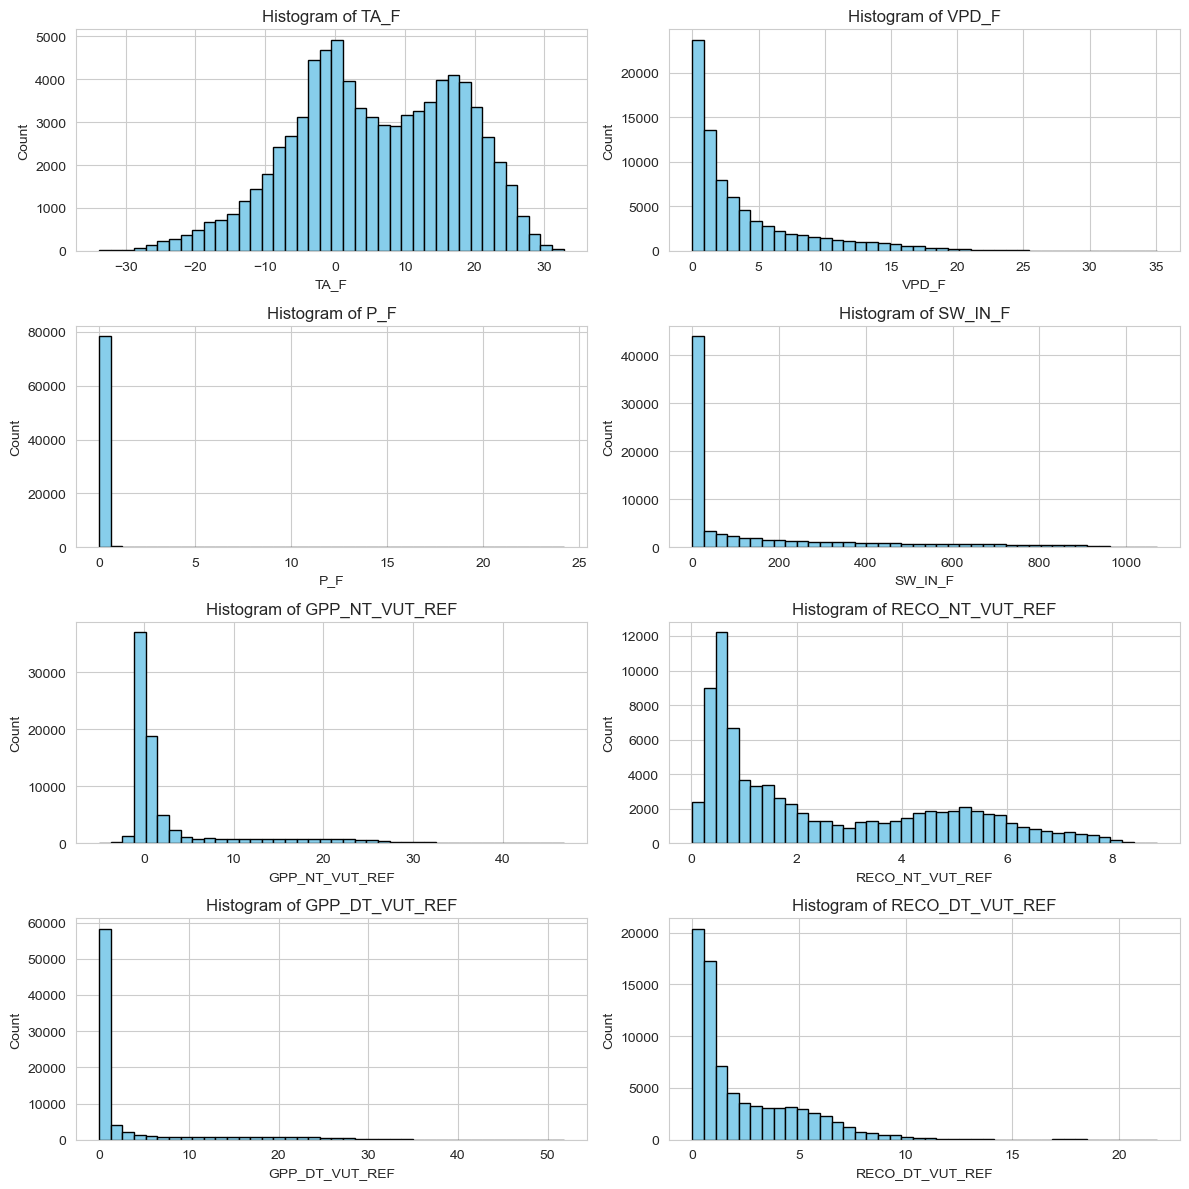

In [9]:
import matplotlib.pyplot as plt

variables = ["TA_F", "VPD_F","P_F", "SW_IN_F", "GPP_NT_VUT_REF", "RECO_NT_VUT_REF",
             'GPP_DT_VUT_REF','RECO_DT_VUT_REF']

plt.figure(figsize=(12, 12))
for i, var in enumerate(variables, 1):
        plt.subplot(4, 2, i)
        df_clean[var].hist(bins=40, color="skyblue", edgecolor="black")
        plt.title(f"Histogram of {var}")
        plt.xlabel(var)
        plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [10]:
df_clean[variables].describe()

,TA_F,VPD_F,P_F,SW_IN_F,GPP_NT_VUT_REF,RECO_NT_VUT_REF,GPP_DT_VUT_REF,RECO_DT_VUT_REF
count,79631.000000,79631.000000,79631.000000,79631.000000,79631.000000,79631.000000,79631.000000,79631.000000
mean,5.860764,3.976407,0.042797,150.886775,3.326116,2.473788,3.310215,2.438264
std,11.718270,4.724018,0.377109,238.512178,7.199892,2.184213,7.175527,2.579997
min,-33.785000,0.000000,0.000000,0.000000,-4.993770,0.019802,0.000000,0.000204
25%,-2.540000,0.716000,0.000000,0.120000,-0.039178,0.604897,0.000000,0.537249
50%,5.556000,2.003000,0.000000,5.085000,0.210916,1.511430,0.023186,1.215220
75%,15.775000,5.427000,0.000000,220.432500,1.944130,4.386205,1.651290,3.908955
max,32.775000,35.075000,24.207000,1070.620000,46.810000,8.843670,51.806800,21.780200


#### Time series

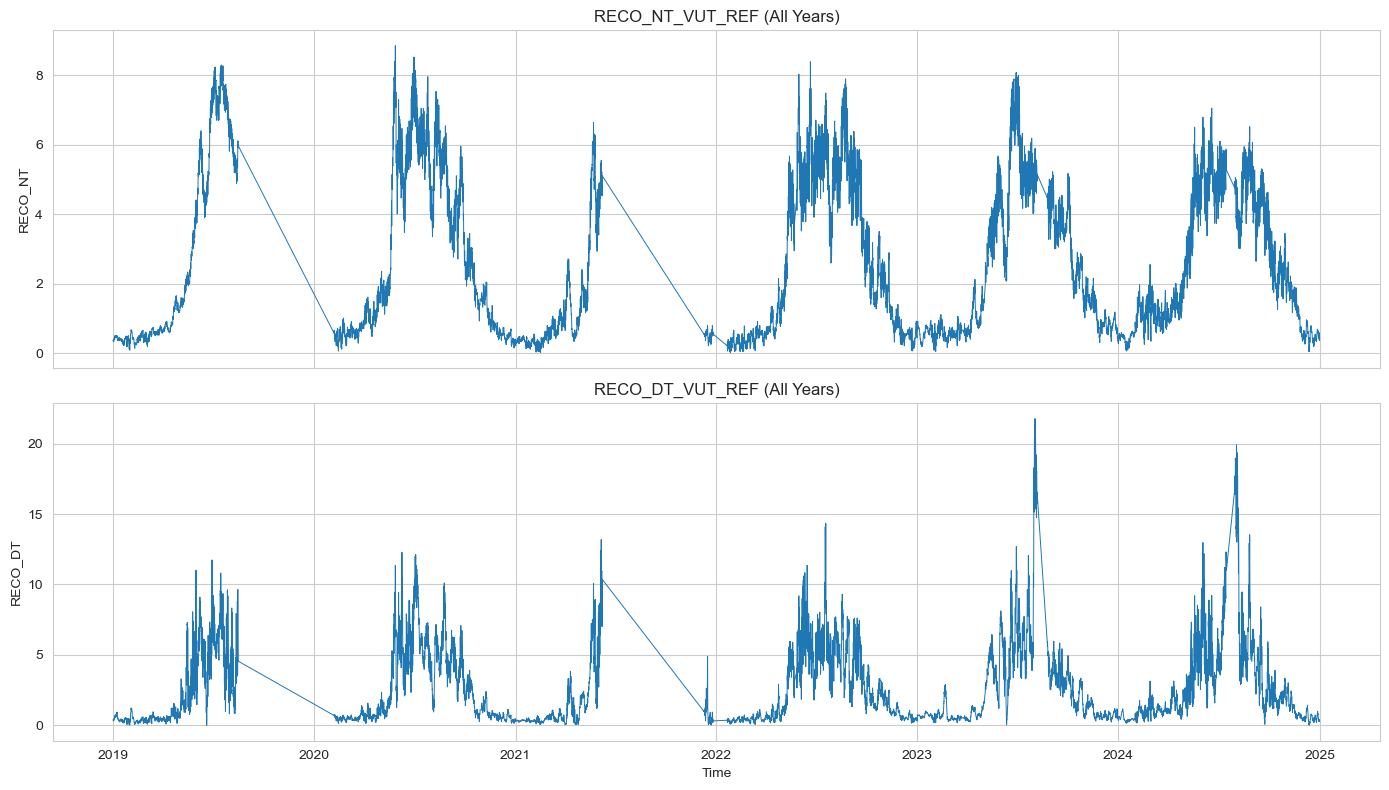

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Upper: RECO_NT_VUT_REF ---
sns.lineplot(
    data=df_clean,
    x="datetime",
    y="RECO_NT_VUT_REF",
    linewidth=0.7,
    ax=axes[0]
)
axes[0].set_title("RECO_NT_VUT_REF (All Years)")
axes[0].set_ylabel("RECO_NT")
axes[0].grid(True)

# --- Lower: RECO_DT_VUT_REF ---
sns.lineplot(
    data=df_clean,
    x="datetime",
    y="RECO_DT_VUT_REF",
    linewidth=0.7,
    ax=axes[1]
)
axes[1].set_title("RECO_DT_VUT_REF (All Years)")
axes[1].set_ylabel("RECO_DT")
axes[1].set_xlabel("Time")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Diurnal cycles

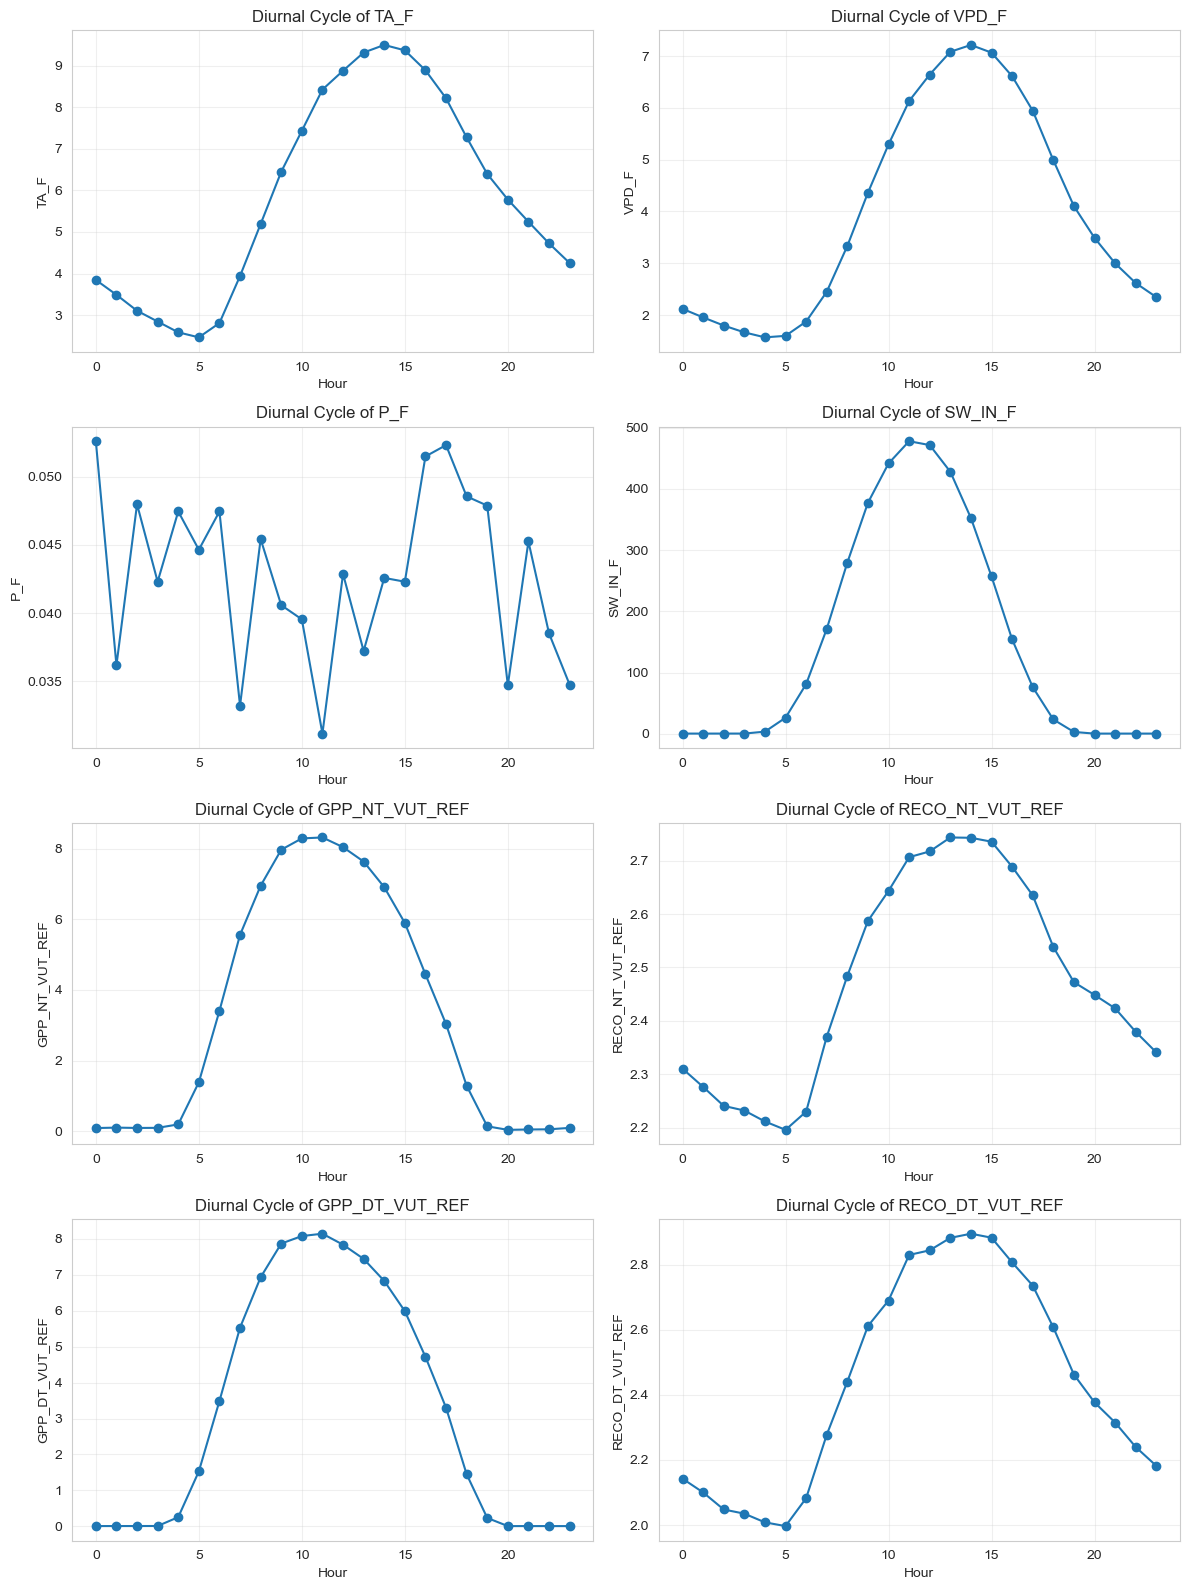

In [13]:
import math
df_clean["hour"] = df_clean["datetime"].dt.hour

# Subplot layout
n = len(variables)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(12, 4 * rows))

for i, var in enumerate(variables, 1):
        diurnal = df_clean.groupby("hour")[var].mean()

        plt.subplot(rows, cols, i)
        plt.plot(diurnal.index, diurnal.values, marker="o")
        plt.title(f"Diurnal Cycle of {var}")
        plt.xlabel("Hour")
        plt.ylabel(var)
        plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

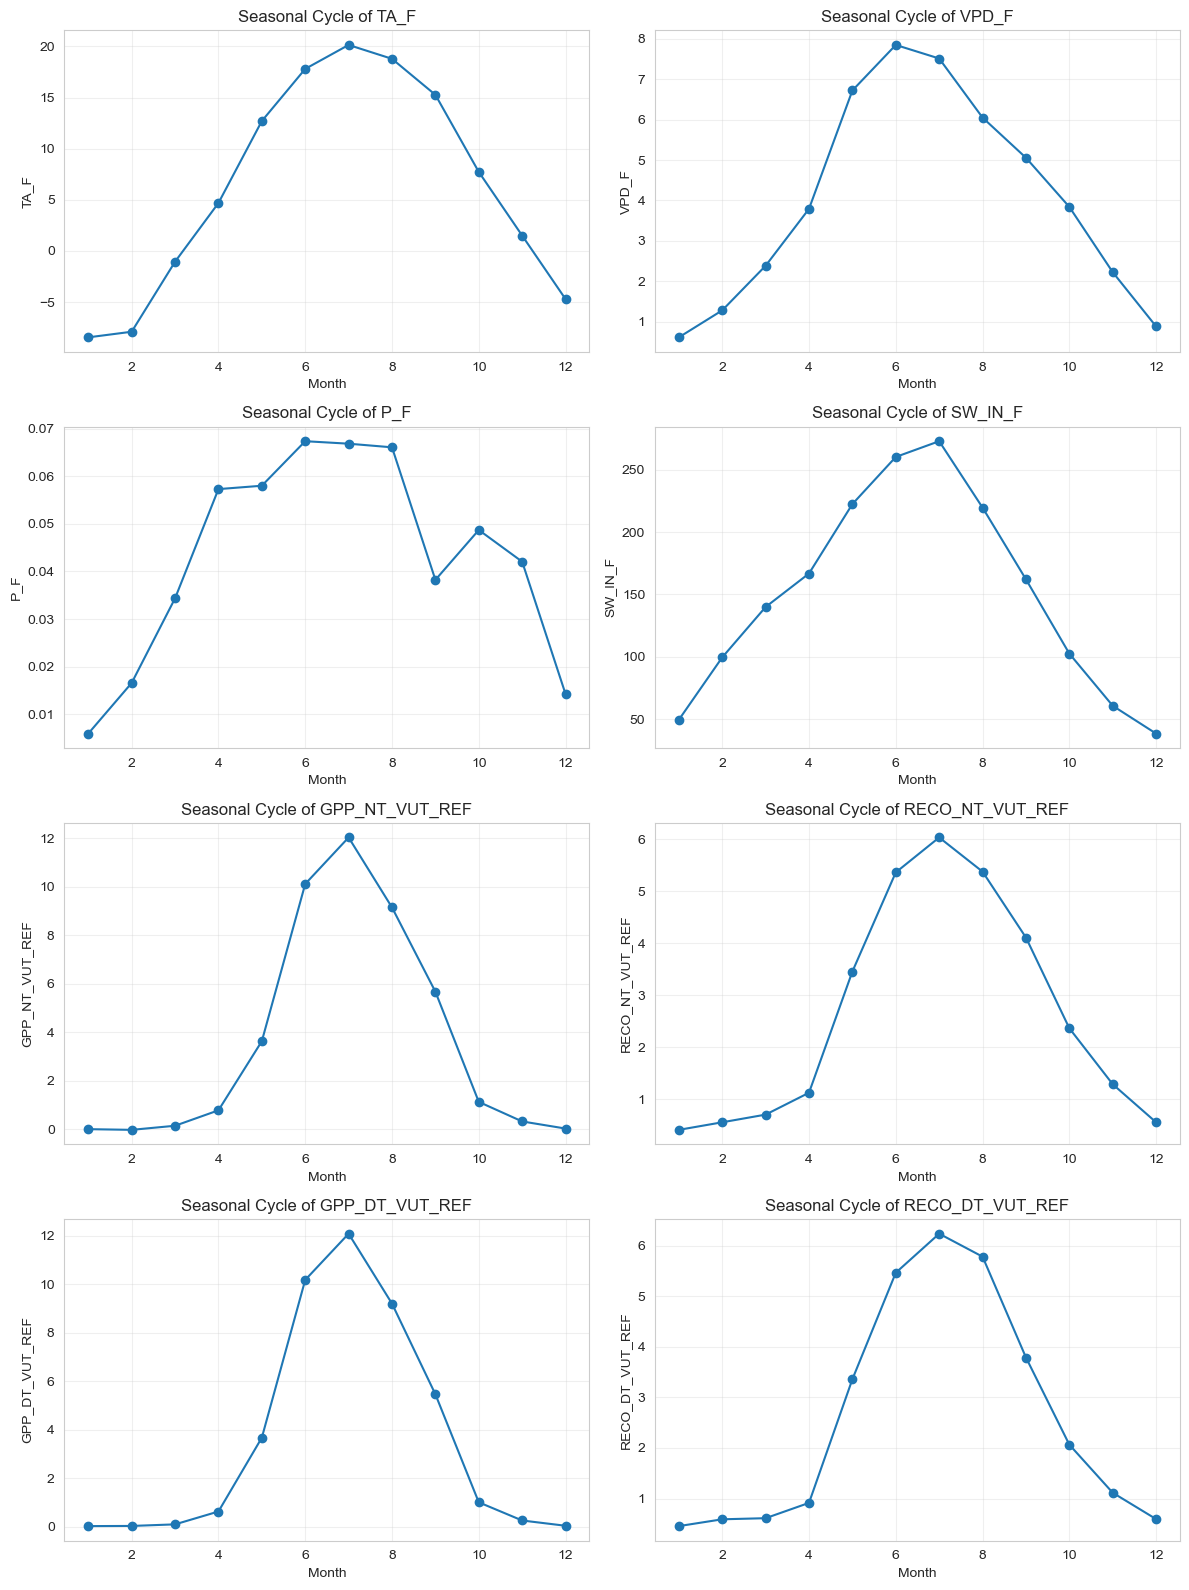

In [14]:
df_clean["month"] = df_clean["datetime"].dt.month

plt.figure(figsize=(12, 4 * rows))

for i, var in enumerate(variables, 1):
        seasonal = df_clean.groupby("month")[var].mean()

        plt.subplot(rows, cols, i)
        plt.plot(seasonal.index, seasonal.values, marker="o")
        plt.title(f"Seasonal Cycle of {var}")
        plt.xlabel("Month")
        plt.ylabel(var)
        plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

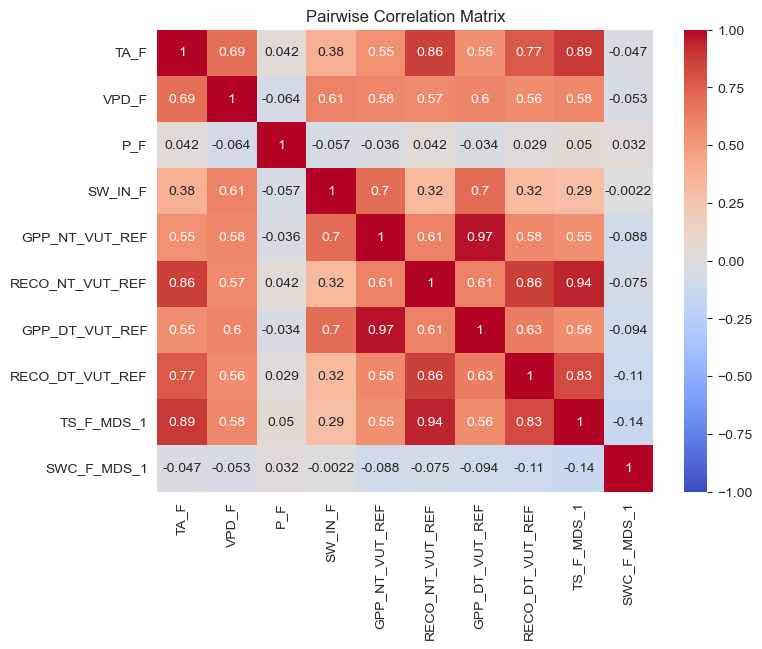

In [15]:
import seaborn as sns

variables_plus = variables + ['TS_F_MDS_1','SWC_F_MDS_1']
corr = df_clean[variables_plus].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pairwise Correlation Matrix")
plt.show()

### scatter plots

In [16]:
df_plot = df_clean[df_clean['year']==2019]

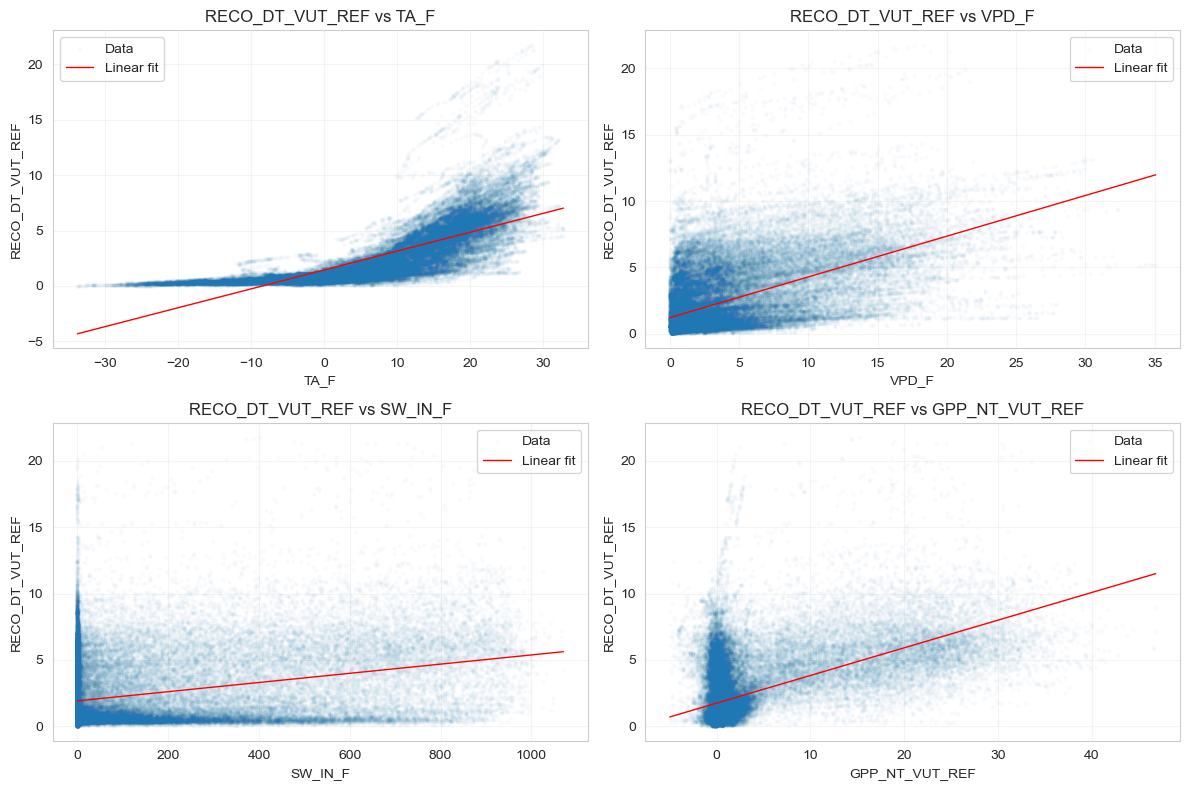

In [24]:
target = "RECO_DT_VUT_REF"
predictors = ["TA_F", "VPD_F", "SW_IN_F", "GPP_NT_VUT_REF"]

# subplot layout
n = len(predictors)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(12, 4 * rows))

for i, var in enumerate(predictors, 1):
    x = df_clean[var]
    y = df_clean[target]

    # Remove NaNs so polyfit won't fail
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    # Fit linear regression y = a*x + b
    a, b = np.polyfit(x_clean, y_clean, deg=1)

    # Generate fitted line
    x_fit = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_fit = a * x_fit + b

    # Plot
    plt.subplot(rows, cols, i)
    plt.scatter(x, y, alpha=0.02, s=4, label="Data")
    plt.plot(x_fit, y_fit, color="red", linewidth=1, label="Linear fit")

    plt.xlabel(var)
    plt.ylabel(target)
    plt.title(f"{target} vs {var}")
    plt.grid(alpha=0.2)
    plt.legend()

plt.tight_layout()
plt.show()

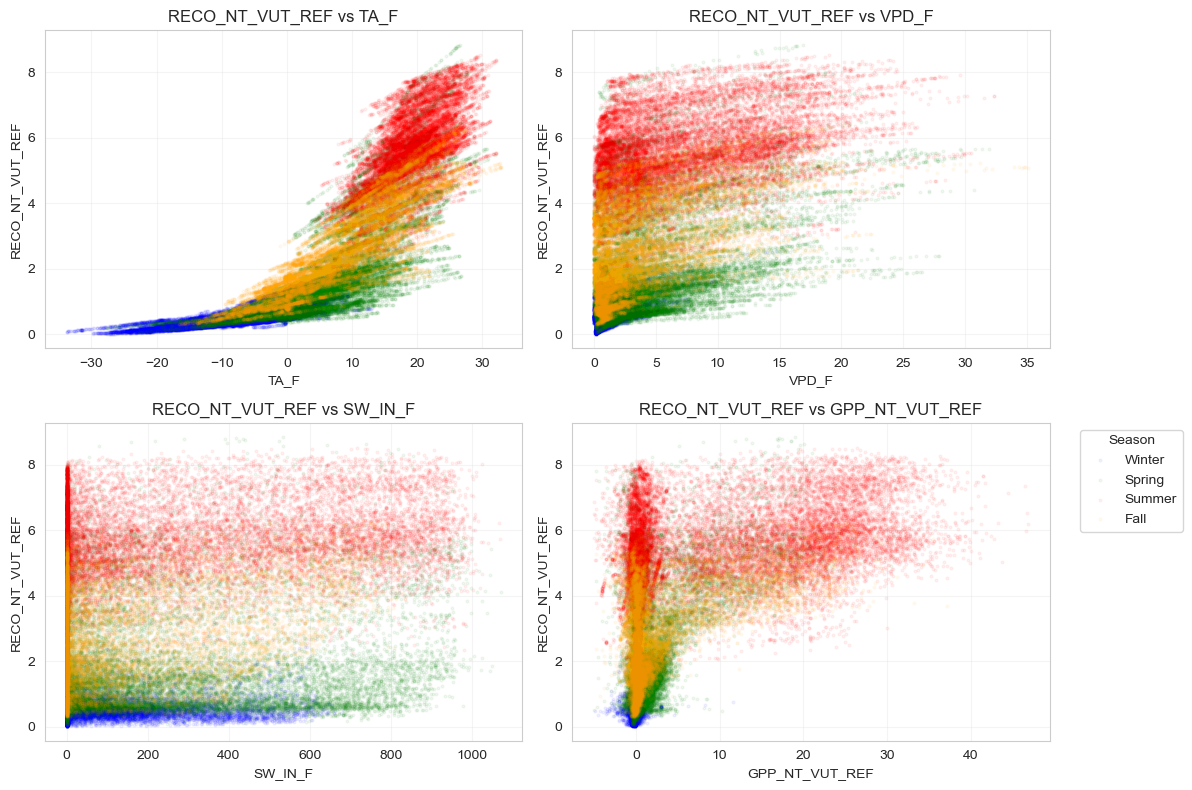

In [25]:
# ---- Define seasons ----
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df_clean["month"] = df_clean["datetime"].dt.month
df_clean["season"] = df_clean["month"].apply(get_season)

# Color map for seasons
season_colors = {
    "Winter": "blue",
    "Spring": "green",
    "Summer": "red",
    "Fall": "orange"
}

# Variables
target = "RECO_NT_VUT_REF"
predictors = ["TA_F", "VPD_F", "SW_IN_F", "GPP_NT_VUT_REF"]

# Layout
n = len(predictors)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(12, 4 * rows))

legend_handles = None  # <- store legend once

for i, var in enumerate(predictors, 1):

    ax = plt.subplot(rows, cols, i)

    for season in ["Winter", "Spring", "Summer", "Fall"]:
        subset = df_clean[df_clean["season"] == season]
        sc = ax.scatter(
            subset[var],
            subset[target],
            s=4,
            alpha=0.05,
            color=season_colors[season],
            label=season
        )

    # Only extract legend handles once (from first subplot)
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.set_xlabel(var)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {var}")
    ax.grid(alpha=0.2)

# Global legend outside plots
plt.legend(
    legend_handles, legend_labels,
    title="Season",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

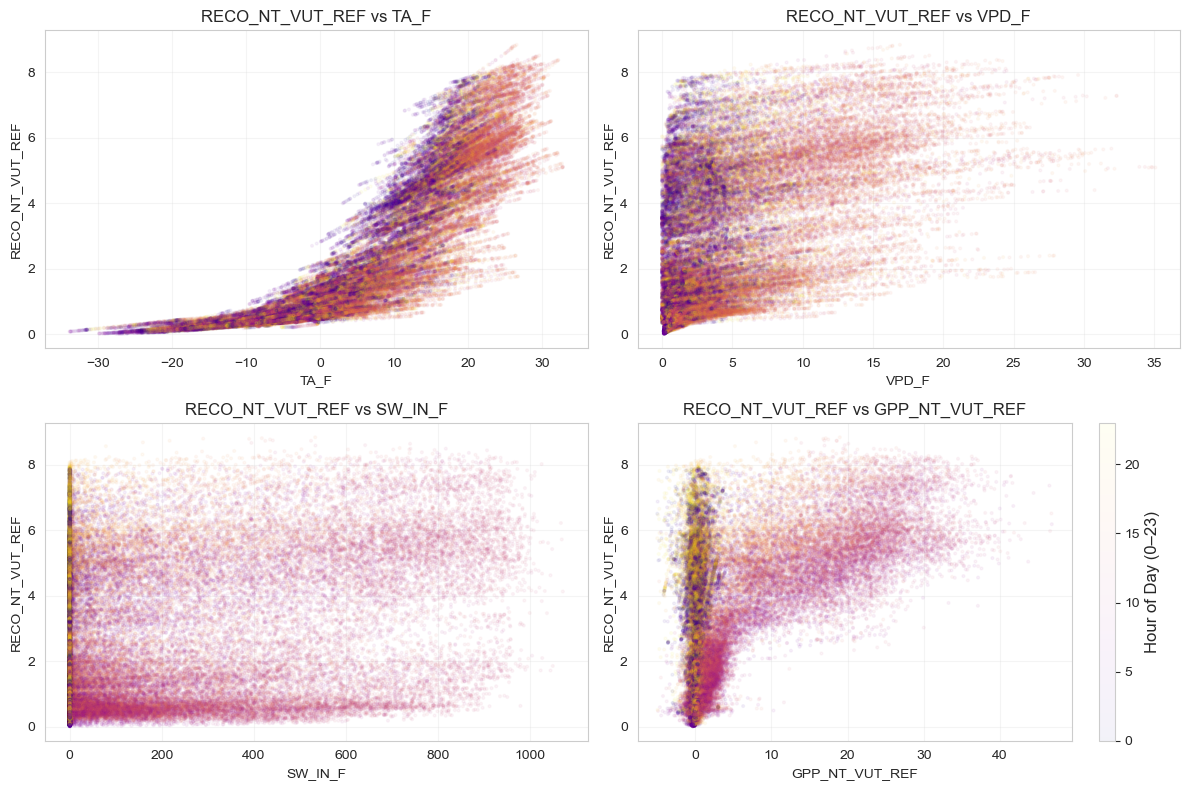

In [26]:
# Color by hour of day
df_clean["hour"] = df_clean["datetime"].dt.hour

target = "RECO_NT_VUT_REF"
predictors = ["TA_F", "VPD_F", "SW_IN_F", "GPP_NT_VUT_REF"]

n = len(predictors)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(12, 4 * rows))

cmap_scatter = plt.cm.plasma  # a bit more vivid than viridis

for i, var in enumerate(predictors, 1):

    ax = plt.subplot(rows, cols, i)

    sc = ax.scatter(
        df_clean[var],
        df_clean[target],
        c=df_clean["hour"],
        cmap=cmap_scatter,
        s=4,
        alpha=0.05,   # very transparent, good for dense data
    )

    ax.set_xlabel(var)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {var}")
    ax.grid(alpha=0.2)

# Add a normal colorbar (alpha of points does NOT affect it)
cbar = plt.colorbar(sc)
cbar.set_label("Hour of Day (0–23)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

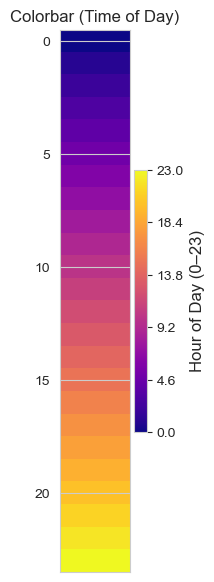

In [27]:
# Choose the same colormap used in scatterplots
cmap = plt.cm.plasma

# Create a simple gradient for the colorbar
gradient = np.linspace(0, 23, 24).reshape(24, 1)

plt.figure(figsize=(2, 6))
plt.imshow(gradient, aspect='auto', cmap=cmap)
plt.gca().set_xticks([])  # no x-axis

# Add a colorbar
cbar = plt.colorbar(
    orientation='vertical',
    ticks=np.linspace(0, 23, 6),  # ticks: 0, ~5, ~10, etc.
)
cbar.set_label("Hour of Day (0–23)", fontsize=12)

plt.title("Colorbar (Time of Day)", fontsize=12)
plt.tight_layout()
plt.show()

Relationships by day

Selected days:
  2022-11-15 (Fall)
  2019-05-10 (Spring)
  2019-06-03 (Summer)
  2022-12-03 (Winter)


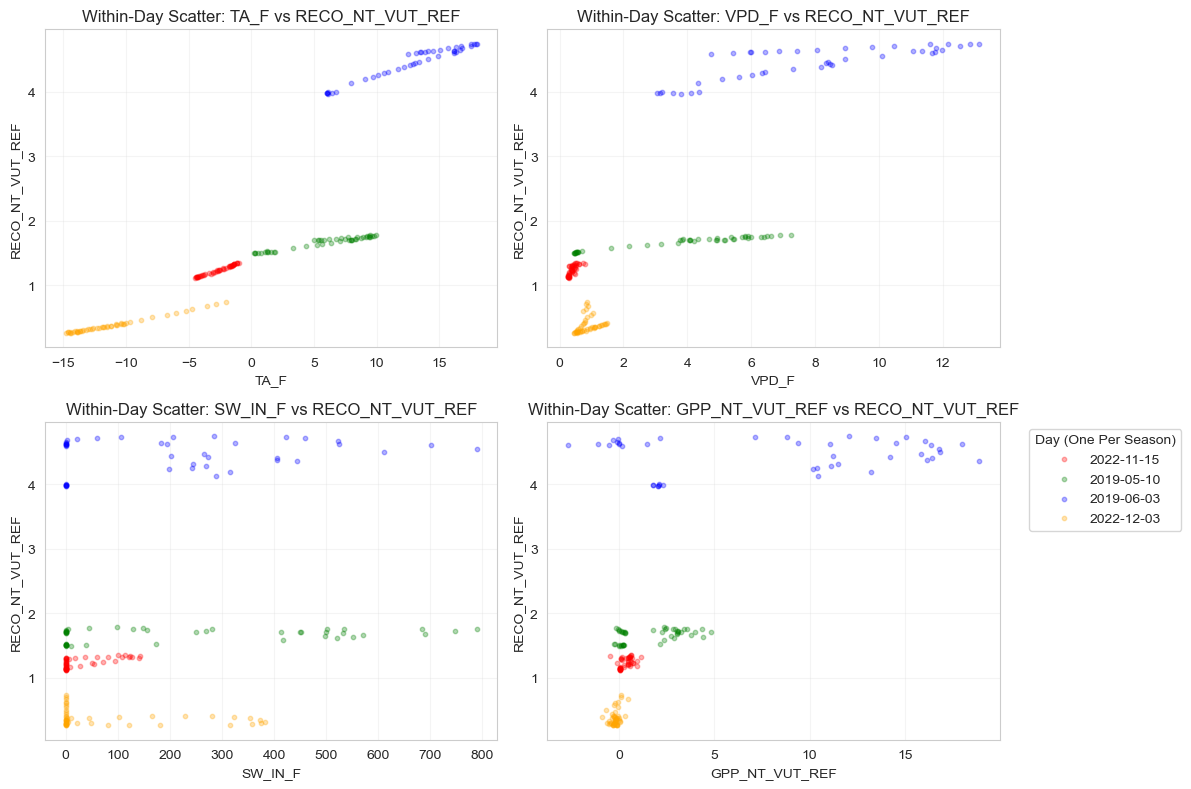

In [28]:
# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df_clean["season"] = df_clean["datetime"].dt.month.apply(get_season)
df_clean["date"] = df_clean["datetime"].dt.date

# Pick 1 random day per season
example_days = (
    df_clean.groupby(["season", "date"])
    .size()
    .reset_index()
    .groupby("season")
    .sample(1, random_state=42)   # fixed for reproducibility
)

selected_dates = example_days["date"].tolist()
selected_seasons = example_days["season"].tolist()

print("Selected days:")
for d, s in zip(selected_dates, selected_seasons):
    print(f"  {d} ({s})")

colors = ["red", "green", "blue", "orange"]
day_colors = dict(zip(selected_dates, colors))


n = len(predictors)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(12, 4 * rows))

for i, var in enumerate(predictors, 1):
    ax = plt.subplot(rows, cols, i)

    for d, c in day_colors.items():
        subset = df_clean[df_clean["date"] == d]

        ax.scatter(
            subset[var],
            subset[target],
            s=10,
            alpha=0.3,
            color=c,
            label=str(d)
        )

    ax.set_xlabel(var)
    ax.set_ylabel(target)
    ax.set_title(f"Within-Day Scatter: {var} vs {target}")
    ax.grid(alpha=0.2)

# One shared legend
plt.legend(
    title="Day (One Per Season)",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

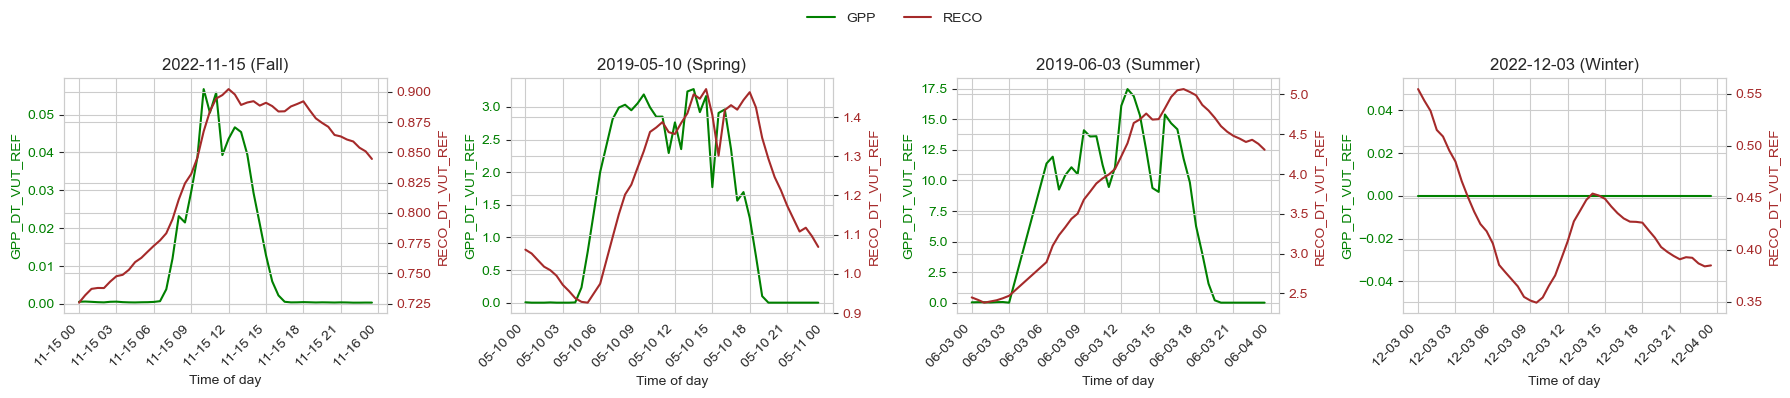

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

for i, (d, season) in enumerate(zip(selected_dates, selected_seasons)):
    ax = axes[i]

    day_data = (
        df_clean[df_clean["date"] == d]
        .sort_values("datetime")
    )

    # Left axis: GPP
    line_gpp, = ax.plot(
        day_data["datetime"],
        day_data["GPP_DT_VUT_REF"],
        color="green",
        label="GPP"
    )
    ax.set_ylabel("GPP_DT_VUT_REF", color="green")
    ax.tick_params(axis="y", labelcolor="green")

    # Right axis: RECO
    ax2 = ax.twinx()
    line_reco, = ax2.plot(
        day_data["datetime"],
        day_data["RECO_DT_VUT_REF"],
        color="brown",
        label="RECO"
    )
    ax2.set_ylabel("RECO_DT_VUT_REF", color="brown")
    ax2.tick_params(axis="y", labelcolor="brown")

    # X-axis formatting
    ax.set_xlabel("Time of day")
    ax.set_title(f"{d} ({season})")

    # Optional: rotate x labels for clarity
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

# One shared legend (GPP, RECO)
fig.legend(
    [line_gpp, line_reco],
    ["GPP", "RECO"],
    loc="upper center",
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for legend at top
plt.show()

/var/folders/dn/x4643hxs0md18z4468bvsg6w0000gn/T/ipykernel_11001/2927582355.py:103: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
/Users/yanghuikang/miniforge3/envs/ml-pytorch/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.


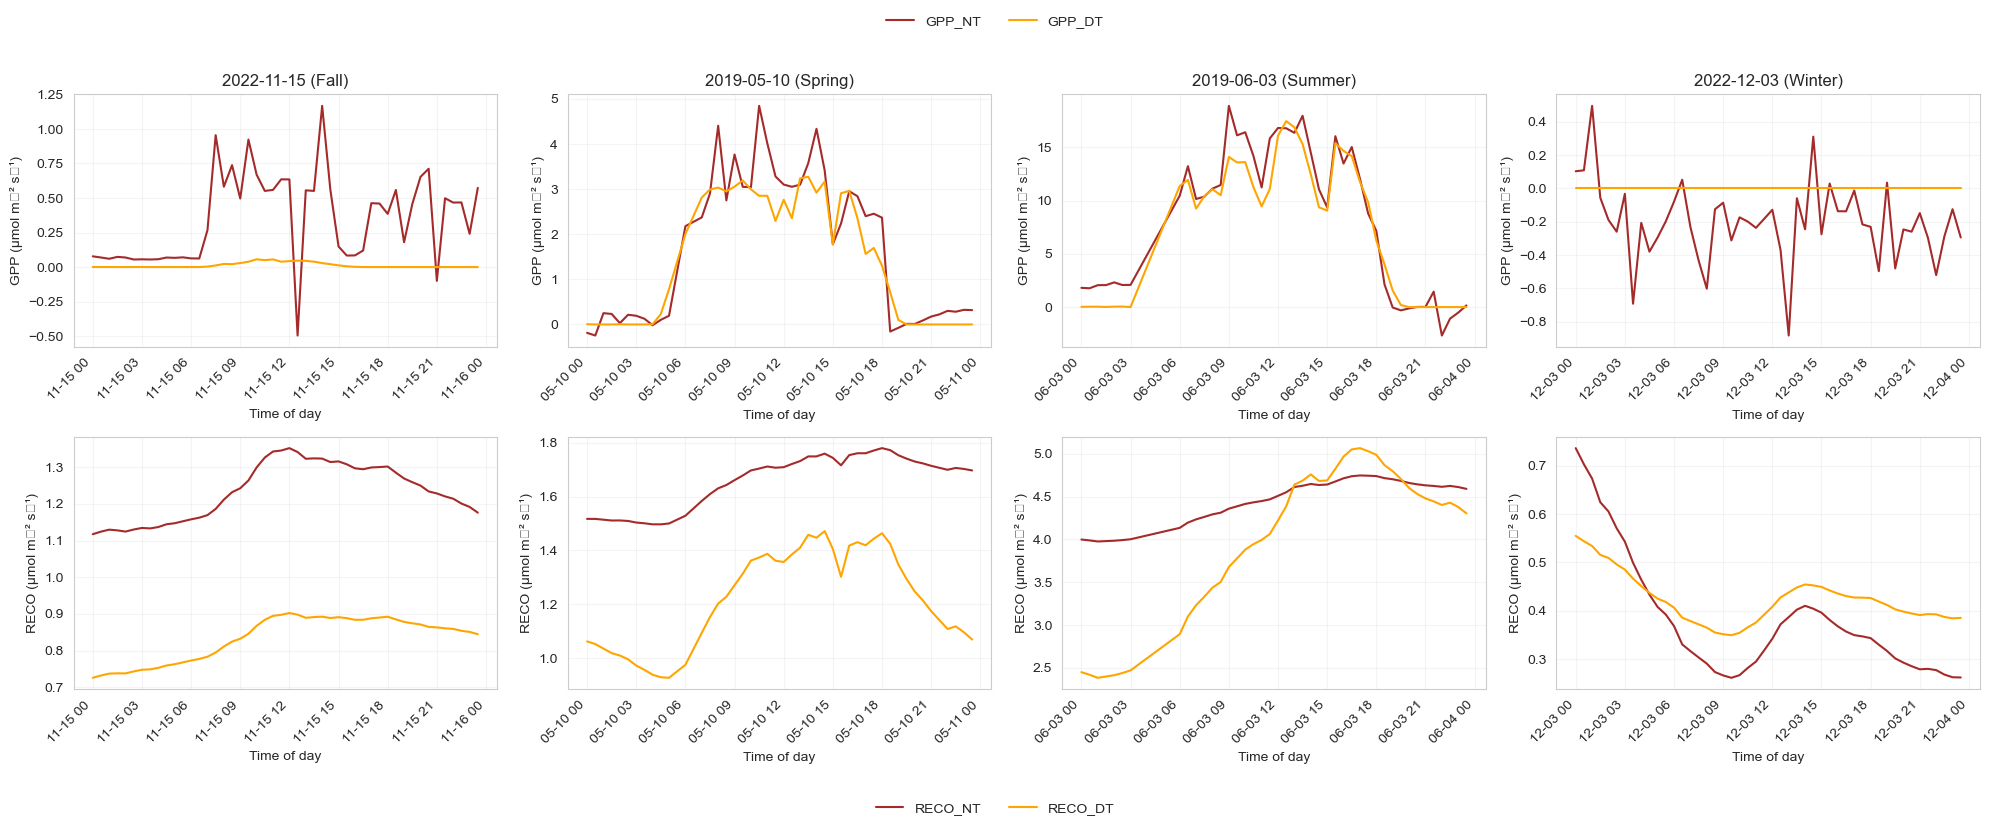

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=False, sharey=False)

# legend handles
h_gpp_nt = h_gpp_dt = None
h_reco_nt = h_reco_dt = None

for col, (d, season) in enumerate(zip(selected_dates, selected_seasons)):

    # Extract daily data
    day_data = (
        df_clean[df_clean["date"] == d]
        .sort_values("datetime")
    )

    # -------------------------
    # Row 1: GPP (NT vs DT)
    # -------------------------
    ax1 = axes[0, col]

    ln1 = ax1.plot(
        day_data["datetime"],
        day_data["GPP_NT_VUT_REF"],
        color="brown",
        label="GPP_NT"
    )[0]

    ln2 = ax1.plot(
        day_data["datetime"],
        day_data["GPP_DT_VUT_REF"],
        color="orange",
        label="GPP_DT"
    )[0]

    # store handles once
    if h_gpp_nt is None:
        h_gpp_nt = ln1
        h_gpp_dt = ln2

    ax1.set_title(f"{d} ({season})", fontsize=12)
    ax1.set_xlabel("Time of day")
    ax1.set_ylabel("GPP (µmol m⁻² s⁻¹)")

    # rotate labels
    for label in ax1.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

    ax1.grid(alpha=0.2)

    # -------------------------
    # Row 2: RECO (NT vs DT)
    # -------------------------
    ax2 = axes[1, col]

    ln3 = ax2.plot(
        day_data["datetime"],
        day_data["RECO_NT_VUT_REF"],
        color="brown",
        label="RECO_NT"
    )[0]

    ln4 = ax2.plot(
        day_data["datetime"],
        day_data["RECO_DT_VUT_REF"],
        color="orange",
        label="RECO_DT"
    )[0]

    if h_reco_nt is None:
        h_reco_nt = ln3
        h_reco_dt = ln4

    ax2.set_xlabel("Time of day")
    ax2.set_ylabel("RECO (µmol m⁻² s⁻¹)")

    for label in ax2.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

    ax2.grid(alpha=0.2)

# -------------------------
# Legends (one for each row)
# -------------------------
fig.legend(
    [h_gpp_nt, h_gpp_dt],
    ["GPP_NT", "GPP_DT"],
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.legend(
    [h_reco_nt, h_reco_dt],
    ["RECO_NT", "RECO_DT"],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01)
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()